In [1]:
import pandas as pd
import json 

with open("raw_data/user_data.json", "r") as file:
    data = json.load(file)


# user_signs_data
# point_events_manual_v2
# user_patterns
# user_attributes
# preferences
# cycles
# profiles
# notes
# aggregates
# plains

In [2]:
# Create dataframes for each data section
df_user_signs_data = pd.DataFrame(data['symptomCheckerData']['user_signs_data']) # de har prosessert denne, etter proessert data

df_profiles = pd.DataFrame(data['operationalData']['profiles'])
df_plains = pd.DataFrame(data['wearablesData']['plains']) 


# you can join some dfs on source_client_version 

In [3]:
"""
Explore user patterns data,

have no idea what this is, it has cycles ids, 
symptom as category and DrawingPain as subcategory
single user_id and patter_id
"""

df_user_patterns = pd.DataFrame(data['operationalData']['user_patterns']) 
df_user_patterns['data'] = df_user_patterns['data'].apply(json.loads)

df_flat_user_patterns = pd.concat(
    [df_user_patterns.drop(columns=['data']),
     pd.json_normalize(df_user_patterns['data'])],
    axis=1
)

In [4]:
"""
Explore symptoms data

Category is the catogory of the symptom, 
subcategory is Nausea and headache for symptom, creamy for Fluid, stress and alcohol for Disturber (Other in the app) etc..
Each symptom has its unique id and there's no other type of identification 
One symptom is logged with per date
"""

df_point_events_manual_v2 = pd.DataFrame(data['operationalData']['point_events_manual_v2']) 

# Filter out unlogged symptoms (subcategory 'N/A')
df_symptoms_cleaned = df_point_events_manual_v2[df_point_events_manual_v2['subcategory'] != 'N/A']
df_notes = pd.DataFrame(data['operationalData']['notes'])

# You can group symptoms by dates - use date column

# Maybe you can join symptoms with cycles? - you can't join them on ids, they are different ids. 
# But you can check if the symptom date is between start and end date of a cycle.

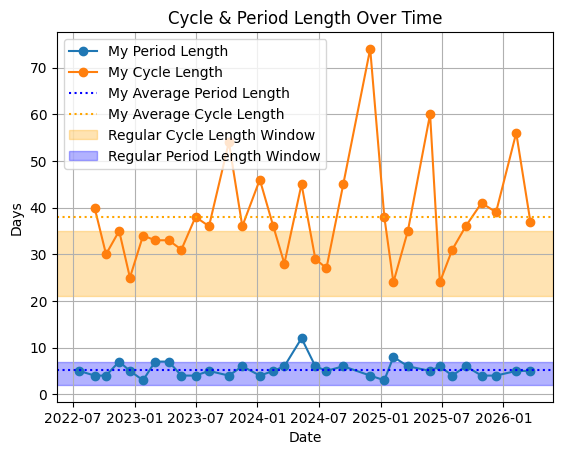

In [5]:
"""
Explore Cycles data
32 cycles, each cycle has a unique id, period_start_date, period_end_date, 

cycle length can be calculated by days between the period_end_date of the last cycle and the period_start_date of the current cycle?

period length can be calculated by period_end_date - period_start_date, 

period intensity: dict, key is the date and value is the intensity level with number
key values: 0 is day 1, 1 is day 2 etc
value: 1 is light, 2 is medium, 3 is heavy, 4 is blood clots. no data on the key means no logged data for that day, so it can be considered as 0.

additonal_fields: json,  has predicted values of the flow prediction models.
"""

import matplotlib.pyplot as plt

df_cycles = pd.DataFrame(data['operationalData']['cycles'])
period_length = (pd.to_datetime(df_cycles['period_end_date']) - pd.to_datetime(df_cycles['period_start_date'])).dt.days
df_cycles['period_length'] = period_length

cycle_length = (pd.to_datetime(df_cycles['period_start_date']) - pd.to_datetime(df_cycles['period_end_date'].shift(1))).dt.days
df_cycles['cycle_length'] = cycle_length

average_period_length = df_cycles['period_length'].mean()
average_cycle_length = df_cycles['cycle_length'].mean()

# --------- Analysis visualization ---------
df_cycles['period_start_date_datetime'] = pd.to_datetime(df_cycles['period_start_date'])
plt.figure()

plt.plot(df_cycles['period_start_date_datetime'], df_cycles['period_length'], '-o', label='My Period Length')
plt.plot(df_cycles['period_start_date_datetime'], df_cycles['cycle_length'], '-o', label='My Cycle Length')
plt.axhline(y = average_period_length, linestyle = 'dotted', color='b', label= 'My Average Period Length')
plt.axhline(y = average_cycle_length, linestyle = 'dotted', color='orange', label= 'My Average Cycle Length')
plt.axhspan(21, 35, alpha=0.3, color='orange', label='Regular Cycle Length Window')
plt.axhspan(2,7, alpha=0.3, color='b', label='Regular Period Length Window' )
plt.legend()
plt.grid()
plt.xlabel("Date")
plt.ylabel("Days")
plt.title("Cycle & Period Length Over Time")
plt.savefig("plots/cycle_analysis.png")
plt.show()




In [17]:

# -------- Unpack period intensity --------
import re

import pandas as pd
import numpy as np
import ast

df_cycles["period_intensity"] = df_cycles["period_intensity"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Expand safely
df_intensity_expanded = df_cycles.join(
    df_cycles["period_intensity"].apply(pd.Series)
)


df_intensity_expanded.rename(columns={
    "0": "Day1",
    "1": "Day2",
    "2": "Day3",
    "3": "Day4",
    "4": "Day5",
    "5": "Day6",
    "6": "Day7",
    "7": "Day8",
    "8": "Day9",
    "9": "Day10"
}, inplace=True)


# after consulting the domain expert/Data owner aka me, i decided to fill the empty values. I fill the empty values between two logged values with the last logged value
# Cuz when my period intensity is the same then i dont log, then i log again when there's change in the period intensity

df_filled = df_intensity_expanded.copy()
day_cols = [f"Day{i}" for i in range(1, 10)]
df_filled[day_cols] = df_filled[day_cols].replace(0, np.nan)

# sort by period start date to make sure the ffill works correctly
day_cols = [col for col in df_filled.columns if col.startswith("Day")]
other_cols = [col for col in df_filled.columns if not col.startswith("Day")]

# Sort only day columns numerically
day_cols_sorted = sorted(day_cols, key=lambda x: int(re.search(r"\d+", x).group()))

# Rebuild dataframe
df_filled = df_filled[other_cols + day_cols_sorted]

# Store original state before filling
df_original = df_filled[day_cols_sorted].copy()

# Fill missing values between logged values with the last logged value
df_filled[day_cols_sorted] = df_filled[day_cols_sorted].ffill(axis=1)

# For each row, set values after the last original non-NaN back to NaN
for idx in df_filled.index:
    row_original = df_original.loc[idx]
    last_non_nan_col = row_original.last_valid_index()
    if last_non_nan_col is not None:
        cols_after = day_cols_sorted[day_cols_sorted.index(last_non_nan_col) + 1:]
        df_filled.loc[idx, cols_after] = np.nan

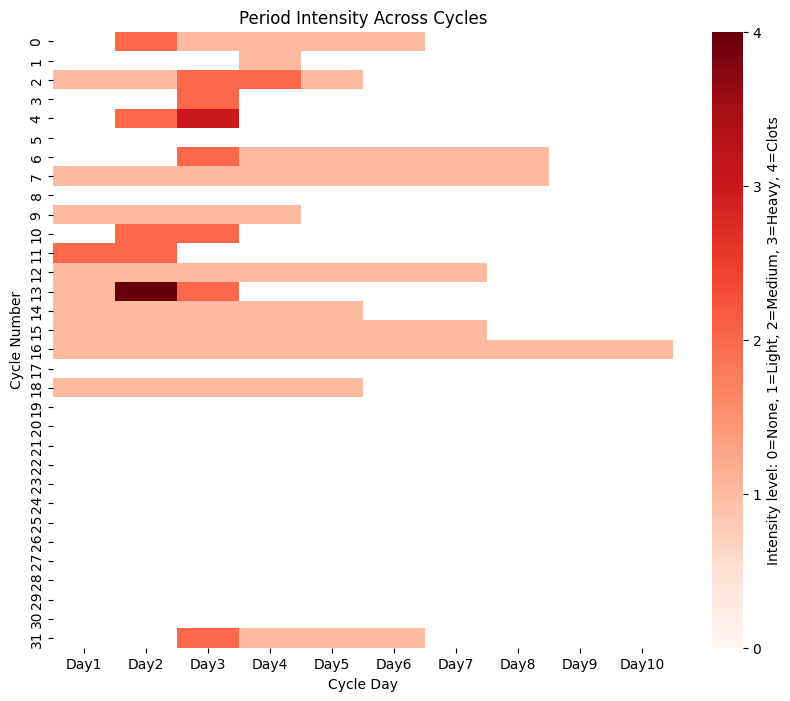

In [ ]:
# --------- Visualization of period intensity ---------

import seaborn as sns
import matplotlib.pyplot as plt


data = df_filled[day_cols_sorted] 
# set intenstiy label på gradient bar

plt.figure(figsize=(10, 8))
sns.heatmap(
    data,
    cmap='Reds',
    vmin=0,
    cbar=True,
    cbar_kws={
        'ticks': [0, 1, 2, 3, 4],
        'label': 'Intensity level: 0=None, 1=Light, 2=Medium, 3=Heavy, 4=Blood Clots'
    }
)
plt.xlabel("Cycle Day")
plt.ylabel("Cycle Number")
plt.title("Period Intensity Across Cycles")
plt.savefig("plots/period_intensity_heatmap.png")
plt.show()

In [8]:
# Analysis checklist:

# Period length, cycle length vs normal period length and cycle length - checked
# Periode intensity i each cycle, maybe how it correlates with symptoms (??)
# Correlation between symptoms with this data set
# Most appeared symptoms overall 
# most appeared symptoms with kyleena 5 years and Jaydess 3 years so far
# Prediction of symptoms per day in cycle
# GitHub pages for analysis results
# check for correlation math
